In [1]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from typing import Callable

class GridConfig:
    """Настройки пространственной и временной сетки"""
    def __init__(self, x1: float, x2: float, t1: float, t2: float, nx: int, courant: float):
        self.x = np.linspace(x1, x2, nx)
        self.nx = nx
        self.dx = (x2 - x1) / (nx - 1)
        self.courant = courant
        self.c = 1.0
        self.dt = courant * self.dx / self.c
        self.t = np.arange(t1, t2 + self.dt, self.dt)
        self.nt = len(self.t)


In [2]:
class WaveFunctions:
    """Функции для волнового уравнения"""
    def __init__(self, k: int = 1):
        self.k = k
    def initial_condition(self, x: np.ndarray) -> np.ndarray:
        return np.sin(self.k * np.pi * x)
    def initial_speed(self, x: np.ndarray) -> np.ndarray:
        return np.sin(self.k * np.pi * x)
    def exact_solution(self, x: np.ndarray, t: float) -> np.ndarray:
        k = self.k
        return np.sin(k * np.pi * x) * (np.cos(k * np.pi * t) + (1/np.pi) * np.sin(k * np.pi * t))


In [3]:
class BaseSolver(ABC):
    def __init__(self, grid: GridConfig, funcs: WaveFunctions):
        self.grid = grid
        self.funcs = funcs
    @abstractmethod
    def solve(self) -> np.ndarray:
        pass


In [4]:
class ExplicitWaveSolver(BaseSolver):
    def solve(self) -> np.ndarray:
        nx, nt = self.grid.nx, self.grid.nt
        u = np.zeros((nt, nx))
        x = self.grid.x
        dt = self.grid.dt
        dx = self.grid.dx
        courant = self.grid.courant
        # Начальные условия
        u[0, :] = self.funcs.initial_condition(x)
        u[1, 1:-1] = u[0, 1:-1] + dt * self.funcs.initial_speed(x[1:-1]) + \
            0.5 * (courant ** 2) * (u[0, 2:] - 2 * u[0, 1:-1] + u[0, :-2])
        u[1, 0] = u[1, -1] = 0.0
        # Временной цикл
        for n in range(1, nt - 1):
            u[n + 1, 1:-1] = 2 * u[n, 1:-1] - u[n - 1, 1:-1] + \
                (courant ** 2) * (u[n, 2:] - 2 * u[n, 1:-1] + u[n, :-2])
            u[n + 1, 0] = u[n + 1, -1] = 0.0
        return u


In [5]:
class SolutionPlotter:
    def plot(self, grid: GridConfig, u: np.ndarray, funcs: WaveFunctions):
        t_indices = [0, grid.nt//4, grid.nt//2, 3*grid.nt//4, grid.nt-1]
        plt.figure(figsize=(10,6))
        for idx in t_indices:
            plt.plot(grid.x, u[idx, :], label=f'Num t={grid.t[idx]:.2f}')
            plt.plot(grid.x, funcs.exact_solution(grid.x, grid.t[idx]), '--', alpha=0.7)
        plt.xlabel('x')
        plt.ylabel('u(x,t)')
        plt.title('Численное и точное решение')
        plt.legend()
        plt.grid(True)
        plt.show()


In [6]:
def demonstrate_dispersion(solver: ExplicitWaveSolver, k: int = 5):
    """
    Демонстрируем численную дисперсию:
    Берём высокочастотное начальное условие (k>1) и сравниваем фазовые скорости
    """
    solver.funcs.k = k
    u = solver.solve()
    grid = solver.grid
    # Сравниваем максимум волны в численном и точном решении
    num_peak_pos = grid.x[np.argmax(u[-1, :])]
    exact_peak_pos = grid.x[np.argmax(solver.funcs.exact_solution(grid.x, grid.t[-1]))]
    phase_shift = num_peak_pos - exact_peak_pos
    # Визуализация
    plt.figure(figsize=(8,5))
    plt.plot(grid.x, u[-1, :], label='Численное решение')
    plt.plot(grid.x, solver.funcs.exact_solution(grid.x, grid.t[-1]), '--', label='Точное решение')
    plt.xlabel('x')
    plt.ylabel('u(x, t_final)')
    plt.title(f'Дисперсия: k={k}, Courant={grid.courant}\nФазовый сдвиг: {phase_shift:.2e}')
    plt.legend()
    plt.grid()
    plt.show()
    print(f'Численная дисперсия: фазовый сдвиг = {phase_shift:.2e}')


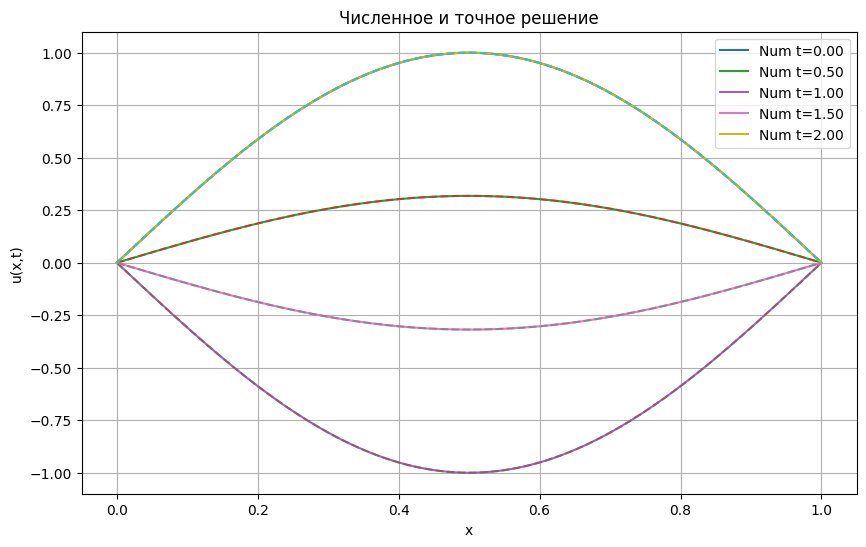

In [24]:
if __name__ == "__main__":
    # Конфигурация
    grid = GridConfig(x1=0, x2=1, t1=0, t2=2, nx=201, courant=1)
    funcs = WaveFunctions(k=1)
    solver = ExplicitWaveSolver(grid, funcs)
    u = solver.solve()
    # Визуализация
    plotter = SolutionPlotter()
    plotter.plot(grid, u, funcs)
    # Демонстрируем численную дисперсию для коротких волн:
    #demonstrate_dispersion(solver, k=30)


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def smooth_delta(x, center=0.5, width=0.03, height=1.0):
    """Сглаженный аналог дельта-функции — узкая шапочка из cos'а."""
    envelope = np.abs(x - center) < width
    profile = np.zeros_like(x)
    profile[envelope] = height * 0.5 * (1 + np.cos(np.pi * (x[envelope] - center) / width))
    return profile

def initial_gaussian(x, center=0.5, sigma=0.02):
    """Гауссов пакет с центром center и шириной sigma"""
    return np.exp(-(x - center)**2 / (2 * sigma**2))


## Фазовая скорость

In [79]:
import numpy as np
import matplotlib.pyplot as plt

def demonstrate_dispersion_delta(solver, courant=1, nx=201, width=0.02, height=1.0, T=None):
    # Установка грид-сетки
    grid = solver.grid
    if nx is not None:
        grid = GridConfig(x1=0, x2=1, t1=0, t2=0.6, nx=nx, courant=courant)
        solver.grid = grid
    # Начальные условия: сглаженная дельта в центре (нулевое смещение, не нулевая скорость!)
    center = 0.5
    solver.funcs.initial_condition = lambda x: smooth_delta(x, center=center, width=width, height=height)
    solver.funcs.initial_speed = lambda x: np.zeros_like(x)
    u = solver.solve()
    # Временные слои для визуализации
    times_to_plot = [0, grid.nt//10, grid.nt//4, grid.nt//2, grid.nt-1]
    plt.figure(figsize=(9,6))
    for idx in times_to_plot:
        plt.plot(grid.x, u[idx, :], label=f"t={grid.t[idx]:.2f}")
    plt.title('Численная дисперсия: Распространение сглаженной дельты')
    plt.xlabel('x')
    plt.ylabel('u(x,t)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- ВЫЧИСЛЕНИЕ ЧИСЛЕННОЙ ФАЗОВОЙ СКОРОСТИ ---
    # Теория: на t>0 дельта делится на две волны, бегущие влево и вправо.
    # Удобно отслеживать максимум правой половинки.
    idx0 = np.argmax(u[0, :])  # в момент t=0 максимум
    idx_last = np.argmax(u[-1, :])  # на последнем временном слое максимум
    x0 = grid.x[idx0]
    x_last = grid.x[idx_last]
    t0 = grid.t[0]
    t_last = grid.t[-1]
    v_phase_num = (x_last - x0) / (t_last - t0)
    v_phase_analytic = 1.0  # по определению для этой задачи
    delta_v = v_phase_analytic - v_phase_num

    print(f"Численная фазовая скорость: {v_phase_num:.5f}")
    print(f"Аналитическая фазовая скорость: {v_phase_analytic:.5f}")
    print(f"Разница фазовых скоростей: {delta_v:.5e} ({100*abs(delta_v/v_phase_analytic):.3f}% отклонение)")
    return v_phase_num, v_phase_analytic, delta_v


In [80]:
def demonstrate_dispersion_gaussian(solver, courant=1, nx=201, sigma=0.02, T=None):
    grid = solver.grid
    if nx is not None:
        grid = GridConfig(x1=0, x2=1, t1=0, t2=solver.grid.t[-1] if T is None else T, nx=nx, courant=courant)
        solver.grid = grid
    solver.funcs.initial_condition = lambda x: initial_gaussian(x, sigma=sigma)
    solver.funcs.initial_speed = lambda x: np.zeros_like(x)
    u = solver.solve()
    times_to_plot = [0, grid.nt//10, grid.nt//4, grid.nt//2, grid.nt-1]
    plt.figure(figsize=(9,6))
    for idx in times_to_plot:
        plt.plot(grid.x, u[idx, :], label=f"t={grid.t[idx]:.2f}")
    plt.title('Численная дисперсия: Распространение Гауссиана')
    plt.xlabel('x')
    plt.ylabel('u(x,t)')
    plt.legend()
    plt.grid(True)
    plt.show()


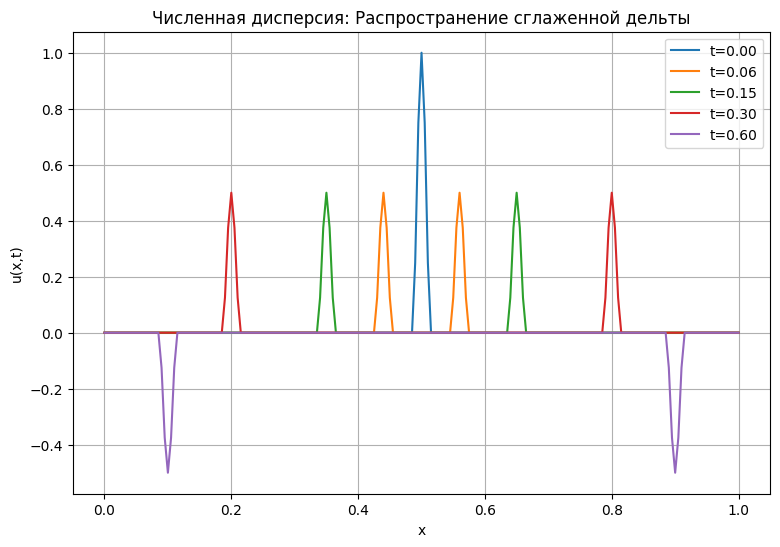

Численная фазовая скорость: -0.83333
Аналитическая фазовая скорость: 1.00000
Разница фазовых скоростей: 1.83333e+00 (183.333% отклонение)


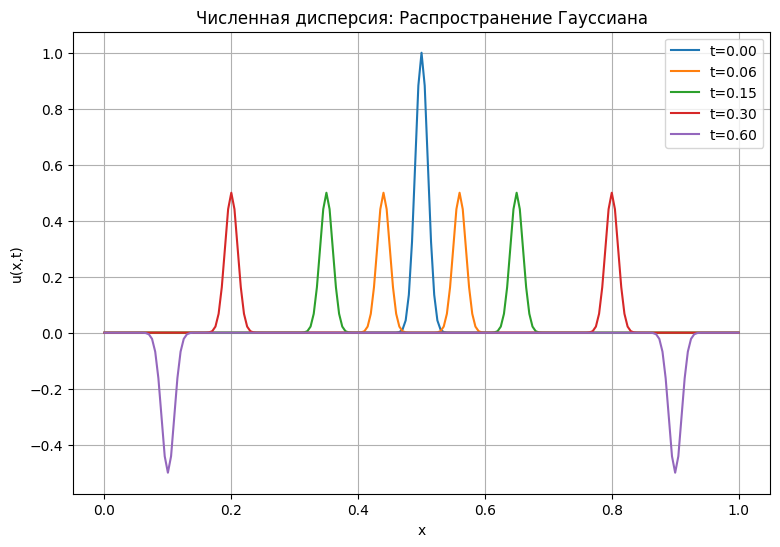

In [81]:
# solver – уже созданный экземпляр класса с grid, funcs и solve()
demonstrate_dispersion_delta(solver, nx=201, width=0.015)
demonstrate_dispersion_gaussian(solver, nx=201, sigma=0.01)


In [37]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

def animate_dispersion_delta(solver, nx=201, width=0.02, height=1.0, gif_name='delta_dispersion.gif', fps=20):
    grid = solver.grid
    # Подготовить новую сетку при необходимости
    if nx != solver.grid.nx:
        grid = GridConfig(x1=0, x2=1, t1=0, t2=solver.grid.t[-1], nx=nx, courant=solver.grid.courant)
        solver.grid = grid
    # Начальные условия
    solver.funcs.initial_condition = lambda x: smooth_delta(x, width=width, height=height)
    solver.funcs.initial_speed = lambda x: np.zeros_like(x)
    u = solver.solve()
    fig, ax = plt.subplots(figsize=(8, 5))
    line, = ax.plot([], [], 'b-', lw=2)
    ax.set_xlim(grid.x[0], grid.x[-1])
    ax.set_ylim(-1.05, 1.05*height)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.set_title('Дисперсия: Сглаженная дельта')
    
    def init():
        line.set_data([], [])
        return (line,)
    def animate(n):
        line.set_data(grid.x, u[n, :])
        ax.set_title(f'Сглаженная дельта, t={grid.t[n]:.2f}')
        return (line,)
    ani = animation.FuncAnimation(fig, animate, frames=grid.nt, init_func=init,
                                  interval=40, blit=True)
    ani.save(gif_name, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)
    print(f'GIF сохранён: {gif_name}')


In [38]:
def animate_dispersion_gaussian(solver, nx=201, sigma=0.02, gif_name='gaussian_dispersion.gif', fps=20):
    grid = solver.grid
    if nx != solver.grid.nx:
        grid = GridConfig(x1=0, x2=1, t1=0, t2=solver.grid.t[-1], nx=nx, courant=solver.grid.courant)
        solver.grid = grid
    solver.funcs.initial_condition = lambda x: initial_gaussian(x, sigma=sigma)
    solver.funcs.initial_speed = lambda x: np.zeros_like(x)
    u = solver.solve()
    fig, ax = plt.subplots(figsize=(8, 5))
    line, = ax.plot([], [], 'r-', lw=2)
    ax.set_xlim(grid.x[0], grid.x[-1])
    ax.set_ylim(-1.05, 1.05)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.set_title('Дисперсия: Гауссиан')
    
    def init():
        line.set_data([], [])
        return (line,)
    def animate(n):
        line.set_data(grid.x, u[n, :])
        ax.set_title(f'Гауссиан, t={grid.t[n]:.2f}')
        return (line,)
    ani = animation.FuncAnimation(fig, animate, frames=grid.nt, init_func=init,
                                  interval=40, blit=True)
    ani.save(gif_name, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)
    print(f'GIF сохранён: {gif_name}')


In [39]:
# Допустим, solver — экземпляр вашего численного класса
animate_dispersion_delta(solver, nx=201, width=0.02, height=1.0, gif_name='delta_dispersion.gif')
animate_dispersion_gaussian(solver, nx=201, sigma=0.02, gif_name='gaussian_dispersion.gif')


GIF сохранён: delta_dispersion.gif
GIF сохранён: gaussian_dispersion.gif
